## Individual Game Logs by Pitch

Baseball Savant's Statcast search provides pitch-level records. The next cells request Statcast data for each batter on a given team in a given season for each pitch they see.

CSV Documentation: https://baseballsavant.mlb.com/csv-docs

In [1]:
from io import StringIO
from pathlib import Path
import pandas as pd
import numpy as np
import requests
from calendar import monthrange
from datetime import date

STATCAST_URL = 'https://baseballsavant.mlb.com/statcast_search/csv'
SEASON = 2026
TEAM = 'NYY' #Team Abbreviation (ex: 'NYY' for Yankees)

CURRENT_DIR = Path.cwd()

DATA_DIR = CURRENT_DIR.parent / 'data'
DATA_DIR.mkdir(exist_ok=True)

RAW_DATA_DIR = DATA_DIR / 'raw'
RAW_DATA_DIR.mkdir(exist_ok=True)

PROCESSED_DATA_DIR = DATA_DIR / 'processed'
PROCESSED_DATA_DIR.mkdir(exist_ok=True)

RAW_DATA_FILE = RAW_DATA_DIR / f'{SEASON}_{TEAM or "all"}_complete_pitch_log.csv'
PA_RESULT_FILE = PROCESSED_DATA_DIR / f'{SEASON}_{TEAM or "all"}_pa_results.csv'
LINE_SCORE_FILE = PROCESSED_DATA_DIR / f'{SEASON}_{TEAM or "all"}_line_scores.csv'

In [ ]:
def get_statcast_month(season, month, team=''):
    start_date = date(season, month, 1)
    end_date = date(season, month, monthrange(season, month)[1])
    params = {
        'all': 'true',
        'type': 'batter',
        'player_type': 'batter',
        'game_type': 'r',
        'hfSea': f'{season}|',
        'hfTeam': f'{team}|' if team else '',
        'game_date_gt': start_date.isoformat(),
        'game_date_lt': end_date.isoformat(),
    }
    response = requests.get(STATCAST_URL, params=params, timeout=120)
    response.raise_for_status()
    if not response.text.strip():
        return pd.DataFrame()
    return pd.read_csv(StringIO(response.text), low_memory=False)

# Truncates dataset to all pitch/swing stats for a given plate appearance where the result was an event (hit, walk, etc.)
def build_plate_appearance_logs(statcast_df, season, team):
    
    hit_events = {'single', 'double', 'triple', 'home_run'}
    non_ab_events = {
        'walk', 'intent_walk', 'hit_by_pitch', 'sac_bunt',
        'sac_fly', 'sac_fly_double_play', 'catcher_interf',
    }
    non_pa_events = {'truncated_pa'} #Ex: runner caught stealing and inning ends (not an official PA for batter)
    non_rbi_events = {'field_error', 'sac_fly_double_play', 'grounded_into_double_play', 'double_play', 'triple_play', 'strikeout_double_play'}

    pa_results = statcast_df[statcast_df['events'].notna()].copy()

    pa_results['batter'] = pd.to_numeric(pa_results['batter'], errors='coerce').astype('Int64')
    pa_results['pa'] = (~pa_results['events'].isin(non_pa_events)).astype(int)
    pa_results['ab'] = (~pa_results['events'].isin(non_ab_events)).astype(int)
    pa_results['h'] = pa_results['events'].isin(hit_events).astype(int)
    pa_results['singles'] = (pa_results['events'] == 'single').astype(int)
    pa_results['doubles'] = (pa_results['events'] == 'double').astype(int)
    pa_results['triples'] = (pa_results['events'] == 'triple').astype(int)
    pa_results['hr'] = (pa_results['events'] == 'home_run').astype(int)

    score_change = (
        pd.to_numeric(pa_results['post_bat_score'], errors='coerce')
        - pd.to_numeric(pa_results['bat_score'], errors='coerce')
    )

    pa_results['rbi'] = score_change.where(~pa_results['events'].isin(non_rbi_events), 0)
    pa_results['bb'] = pa_results['events'].isin({'walk', 'intent_walk'}).astype(int)
    pa_results['hbp'] = (pa_results['events'] == 'hit_by_pitch').astype(int)
    pa_results['so'] = pa_results['events'].isin({'strikeout', 'strikeout_double_play'}).astype(int)
    pa_results['sb'] = pa_results['events'].str.startswith('stolen_base', na=False).astype(int)
    pa_results['cs'] = pa_results['events'].str.startswith('caught_stealing', na=False).astype(int)
    pa_results['tb'] = (
        pa_results['singles']
        + (2 * pa_results['doubles'])
        + (3 * pa_results['triples'])
        + (4 * pa_results['hr'])
    )

    return pa_results

# Groups plate appearances by game and player, summing the relevant stats to create a game log for each player in each game
def build_game_logs(pa_results, season, team):
    if pa_results.empty:
        return pd.DataFrame()

    pa_results = pa_results.copy()
    
    pa_results['opposing_team'] = np.where(
        pa_results['home_team'] == team,
        pa_results['away_team'],
        pa_results['home_team']
    )

    group_columns = ['game_pk', 'game_date', 'batter', 'player_name', 'opposing_team']
    game_logs = pa_results.groupby(group_columns, as_index=False)[[
        'pa', 'ab', 'h', 'singles', 'doubles', 'triples', 'hr',
        'bb', 'hbp', 'so', 'sb', 'cs', 'rbi', 'tb',
    ]].sum()

    game_logs = game_logs.rename(columns={'batter': 'player_id'})
    game_logs['season'] = season
    
    #game_logs.head(50)

    return game_logs

def pa_statcast_data(statcast_df, season, team):

    desc_df = statcast_df[statcast_df['description'].notna()].copy()
   
    # Calculate plate appearances and at bats based on the events column, where certain events do not count as official plate appearances or at bats
    non_ab_events = {
        'walk', 'intent_walk', 'hit_by_pitch', 'sac_bunt',
        'sac_fly', 'sac_fly_double_play', 'catcher_interf',
    }
    non_pa_events = {'truncated_pa'} #Ex: runner caught stealing and inning ends (not an official PA for batter)
    desc_df['pa'] = (~desc_df['events'].isin(non_pa_events)).astype(int)
    desc_df['ab'] = (~desc_df['events'].isin(non_ab_events)).astype(int)

    # Handle missing pitch types for automatic balls/strikes, naming the pitch type as "AUTO"
    desc_df['pitch_type'] = np.where((desc_df['description'].str.contains('automatic', na=False)) & (desc_df['pitch_type'].isna()), "AUTO", desc_df['pitch_type'])

    # Count each pitch type for the plate appearance grouped by game and at-bat. Keep NaN values for rows missing pitch types (not including automatic balls/strikes)
    pitch_type_counts = (
        desc_df.groupby(['game_pk', 'at_bat_number', 'pitch_type'], dropna=False)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    pitch_type_counts.columns.name = None

    pitch_cols = [col for col in pitch_type_counts.columns if col not in {'game_pk', 'at_bat_number'}]
    for col in pitch_cols:
        pitch_type_counts[col] = pitch_type_counts[col].fillna(0).astype(int)

    # Get a list of unique result types from the 'description' column
    pitch_result_events = desc_df['description'].unique()
    pitch_result_events = pd.Series(pitch_result_events).to_dict()

    desc_df['swings'] = desc_df.groupby(['game_pk', 'at_bat_number'])['description'].transform(
        lambda x: x.isin({
            'hit_into_play', 'swinging_strike', 'foul', 'foul_tip',
            'swinging_strike_blocked', 'foul_bunt', 'missed_bunt',
            'bunt_foul_tip'
        }).sum()
        ).astype(int) # Count of all swings

    desc_df['pitches'] = desc_df.groupby(['game_pk', 'at_bat_number'])['description'].transform('count').astype(int) # Count of all pitches
    desc_df['balls'] = desc_df.groupby(['game_pk', 'at_bat_number'])['type'].transform(
        lambda x: x.isin({'B'}).sum()
        ).astype(int) # Count of all balls
    desc_df['strikes'] = desc_df.groupby(['game_pk', 'at_bat_number'])['type'].transform(
        lambda x: x.isin({'S'}).sum()
        ).astype(int) # Count of all strikes
    desc_df['in_play'] = desc_df.groupby(['game_pk', 'at_bat_number'])['type'].transform(
        lambda x: x.isin({'X'}).sum()
        ).astype(int) # Count of all strikes
        
    # Combine original df with pitch type counts for each plate appearance
    pa_statcast_df = desc_df[desc_df['events'].notna()].copy()
    pa_statcast_df = pa_statcast_df.merge(
        pitch_type_counts,
        on=['game_pk', 'at_bat_number'],
        how='left'
    )

    for col in pitch_cols:
        pa_statcast_df[col] = pa_statcast_df[col].fillna(0).astype(int)


    ## More granular, smaller dataframe for season-long analysis for individual players
    group_cols = ['batter', 'player_name']
    pitches_by_player_cols = ['pa', 'ab', 'pitches', 'balls', 'strikes', 'in_play', 'swings'] + pitch_cols
    pitches_by_player = pa_statcast_df.groupby(group_cols, as_index=False)[
        pitches_by_player_cols
    ].sum().reset_index(drop=True)
    pitches_by_player['season'] = season


    return pa_statcast_df, pitches_by_player


In [ ]:
# Run data retrieval for each month of the season into a single dataframe
monthly_statcast = []
for month in range(1, 13):
    month_df = get_statcast_month(SEASON, month, TEAM)
    if not month_df.empty:
        monthly_statcast.append(month_df)
    print(f'Processed month {month}/12; pitch rows: {sum(len(df) for df in monthly_statcast)}')

statcast_df = pd.concat(monthly_statcast, ignore_index=True)
statcast_df = statcast_df.dropna(how='all', axis=1) # Drop empty columns
statcast_df = statcast_df.loc[:, ~statcast_df.columns.str.startswith('fielder')] # Drop columns with no useful info
statcast_df = statcast_df[statcast_df['game_type'] == 'R']  # Filter for regular season games only
statcast_df['pitch_type_id'] = statcast_df['pitch_type'].factorize()[0] # Enumerate pitch types for easier analysis and modeling
statcast_df['on_1b'] = statcast_df['on_1b'].fillna(0).astype(int) # Replace missing values with 0 for runners on base
statcast_df['on_2b'] = statcast_df['on_2b'].fillna(0).astype(int)
statcast_df['on_3b'] = statcast_df['on_3b'].fillna(0).astype(int)
statcast_df.loc[statcast_df['on_1b'] > 1, 'on_1b'] = 1 # Cap runners on base at 1 for each base
statcast_df.loc[statcast_df['on_2b'] > 1, 'on_2b'] = 1
statcast_df.loc[statcast_df['on_3b'] > 1, 'on_3b'] = 1
statcast_df.to_csv(RAW_DATA_FILE, index=False, encoding='utf-8') #utf-8-sig for excel

Processed month 1/12; pitch rows: 0
Processed month 2/12; pitch rows: 1440
Processed month 3/12; pitch rows: 5367
Processed month 4/12; pitch rows: 9361
Processed month 5/12; pitch rows: 13636
Processed month 6/12; pitch rows: 17394
Processed month 7/12; pitch rows: 21065
Processed month 8/12; pitch rows: 25183
Processed month 9/12; pitch rows: 27583
Processed month 10/12; pitch rows: 27583
Processed month 11/12; pitch rows: 27583
Processed month 12/12; pitch rows: 27583


In [4]:
# Process and break up entire pitch log dataset into plate appearance and individual game line score datasets
if not statcast_df.empty:
    pa_df = build_plate_appearance_logs(statcast_df, SEASON, TEAM)
    pa_df.to_csv(PA_RESULT_FILE, index=False, encoding='utf-8')
    print(f'Wrote {len(pa_df)} plate appearance result rows to {PA_RESULT_FILE}')
    if not pa_df.empty:
        line_score_df = build_game_logs(pa_df, SEASON, TEAM)
        line_score_df.to_csv(LINE_SCORE_FILE, index=False, encoding='utf-8')
        print(f'Wrote {len(line_score_df)} player-game rows to {LINE_SCORE_FILE}')
else:
    statcast_df = pd.DataFrame()
    pa_df = pd.DataFrame()
    print('No Statcast game-log data was found.')

Wrote 5762 plate appearance result rows to /mnt/c/users/noahj/documents/2026/game-score-model/data/processed/2026_NYY_pa_results.csv
Wrote 1568 player-game rows to /mnt/c/users/noahj/documents/2026/game-score-model/data/processed/2026_NYY_line_scores.csv


In [9]:
pa_statcast, by_player = pa_statcast_data(statcast_df, SEASON, TEAM)
pa_statcast.describe(include='all')
by_player.head(50)

,batter,player_name,pa,ab,pitches,balls,strikes,in_play,swings,AUTO,...,FS,KC,PO,SI,SL,ST,SV,UN,NaN,season
0,502671,"Goldschmidt, Paul",370,336,1468,494,721,253,705,8,...,29,19,0,261,246,125,6,0,3,2026
1,519317,"Stanton, Giancarlo",96,90,384,146,177,61,173,0,...,7,5,0,67,54,36,0,0,0,2026
2,545341,"Grichuk, Randal",33,31,120,41,57,22,57,0,...,1,1,0,14,15,6,0,0,0,2026
3,592450,"Judge, Aaron",285,237,1234,501,580,153,527,17,...,43,6,0,187,210,100,5,0,0,2026
4,641355,"Bellinger, Cody",542,478,2025,745,879,401,952,3,...,92,23,0,332,251,140,4,0,1,2026
5,641555,"Escarra, J.C.",92,85,350,129,153,68,160,0,...,16,6,0,44,40,28,1,0,0,2026
6,641857,"McMahon, Ryan",350,319,1430,508,704,218,654,2,...,63,30,2,167,186,112,2,0,3,2026
7,642708,"Rosario, Amed",236,219,856,264,426,166,472,1,...,14,9,0,146,120,68,7,0,0,2026
8,645305,"Sánchez, Ali",81,76,285,93,138,54,141,0,...,3,0,0,64,24,18,1,0,0,2026
9,663757,"Grisham, Trent",484,419,1965,809,823,333,768,0,...,81,29,0,344,215,143,5,1,0,2026


## Important Considerations for Game Score
- Chases and how bad was the chase (miss distance, bat speed)
- Velocity / spin rate correlation based on pitch type
- Situation (runners on, inning, num outs)
- Exit velo / hit distance / xBA
- Result for plate appearances (type of event, RBIs, WPA)


## First Model

Predict line score based on a few factors like previous games' line scores & team matchup

In [6]:
line_score_df.describe(include='all')

,game_pk,game_date,player_id,player_name,opposing_team,pa,ab,h,singles,doubles,triples,hr,bb,hbp,so,sb,cs,rbi,tb,season
count,1568.000000,1568,1568.0,1568,1568,1568.000000,1568.000000,1568.000000,1568.000000,1568.000000,1568.00000,1568.000000,1568.000000,1568.000000,1568.000000,1568.0,1568.0,1568.000000,1568.000000,1568.0
unique,NaN,151,<NA>,22,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2026-08-29,<NA>,"Rice, Ben",BOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,23,<NA>,147,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,823707.961735,NaN,653588.370536,NaN,NaN,3.665816,3.264031,0.764031,0.478954,0.137755,0.01148,0.135842,0.352041,0.023597,0.897321,0.0,0.0,0.436862,1.332270,2026.0
std,586.606117,NaN,54774.537996,NaN,NaN,1.158991,1.180757,0.836580,0.674688,0.371483,0.10656,0.364389,0.623755,0.151838,0.872346,0.0,0.0,0.850597,1.767589,0.0
min,822708.000000,NaN,502671.0,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,2026.0
25%,823501.750000,NaN,641857.0,NaN,NaN,3.000000,3.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,2026.0
50%,823540.000000,NaN,665862.0,NaN,NaN,4.000000,4.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.000000,1.000000,2026.0
75%,823983.250000,NaN,680474.0,NaN,NaN,4.000000,4.000000,1.000000,1.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.0,0.0,1.000000,2.000000,2026.0


In [7]:
line_score_df.corr(numeric_only=True)

,game_pk,player_id,pa,ab,h,singles,doubles,triples,hr,bb,hbp,so,sb,cs,rbi,tb,season
game_pk,1.000000,-0.012456,0.035115,0.028523,0.002140,0.030383,-0.033478,0.015852,-0.021848,0.019342,-0.006159,-0.002063,NaN,NaN,0.015191,-0.017623,NaN
player_id,-0.012456,1.000000,0.036417,0.021125,-0.007676,0.002618,-0.014996,0.026749,-0.015005,0.021033,0.022524,0.012164,NaN,NaN,-0.017445,-0.012839,NaN
pa,0.035115,0.036417,1.000000,0.839086,0.395138,0.295408,0.151459,0.077587,0.183113,0.256411,0.004949,0.216623,NaN,NaN,0.247874,0.341447,NaN
ab,0.028523,0.021125,0.839086,1.000000,0.410039,0.305777,0.157084,0.051975,0.199881,-0.266653,-0.102404,0.297083,NaN,NaN,0.224384,0.356964,NaN
h,0.002140,-0.007676,0.395138,0.410039,1.000000,0.778113,0.383933,0.109151,0.431793,-0.030262,-0.026472,-0.163514,NaN,NaN,0.521618,0.834181,NaN
singles,0.030383,0.002618,0.295408,0.305777,0.778113,1.000000,-0.067357,-0.005514,0.005147,-0.020293,-0.041870,-0.131076,NaN,NaN,0.165595,0.356635,NaN
doubles,-0.033478,-0.014996,0.151459,0.157084,0.383933,-0.067357,1.000000,-0.007732,-0.011040,-0.019391,0.055473,-0.076450,NaN,NaN,0.132563,0.384115,NaN
triples,0.015852,0.026749,0.077587,0.051975,0.109151,-0.005514,-0.007732,1.000000,-0.023751,0.044773,-0.016753,-0.042233,NaN,NaN,0.155855,0.155917,NaN
hr,-0.021848,-0.015005,0.183113,0.199881,0.431793,0.005147,-0.011040,-0.023751,1.000000,-0.025226,-0.034904,-0.042419,NaN,NaN,0.710224,0.817631,NaN
bb,0.019342,0.021033,0.256411,-0.266653,-0.030262,-0.020293,-0.019391,0.044773,-0.025226,1.000000,-0.040600,-0.135250,NaN,NaN,-0.004989,-0.028601,NaN


## Potentially Important Features for a More Complex Model:

1. Pitch Type - need to enumerate
2. Game Date ?
3. pfx_x and pfx_z (horizontal and vertical movement, respectively, of pitch from release to crossing plate, from catcher's perspective)
4. Zone:

    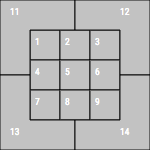

5. Event - need to enumerate
6. Stand (batter L/R), p_throws (pitcher L/R)
7. Type (ball/strike/in play) - enumerate
8. Hit location (pos. of fielder)
9. bb_type (batted ball type - line drive, fly ball, etc) - enumerate
10. Count (balls / strikes)
11. Runners on
12. Current # of outs
13. Inning
14. sz_top / sz_bot (top/bottom of batter's strike zone}
15. hit_distance
16. launch_speed
17. effective_speed (derived speed based on pitcher's extension)
18. release_pos_y (release position of pitch measured in feet from the catcher's perspective)
19. release_spin (spin rate)
20. release_extension
21. arm_angle
22. score before/after event
23. bat_speed
24. swing_length
25. miss_distance
